### 1. Dataset Overview

In [47]:
import pandas as pd
import numpy as np
df = pd.read_excel("../data/cleaned_japan.xlsx")
print(df.shape)
print(df.info())
print(df.head())

(25849, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25849 entries, 0 to 25848
Data columns (total 18 columns):
 #   Column                                                                                    Non-Null Count  Dtype         
---  ------                                                                                    --------------  -----         
 0   certification_body_code                                                                   25849 non-null  object        
 1   certification_number                                                                      25849 non-null  object        
 2   certification_date                                                                        25849 non-null  datetime64[ns]
 3   sales_name                                                                                25849 non-null  object        
 4   general_name                                                                              25849 non-null  object      

In [48]:
overview_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Count": df.isnull().sum().values,
    "Missing Ratio (%)": (df.isnull().mean() * 100).round(2).values,
})

overview_df.index = overview_df.index + 1

overview_df

,Column,Data Type,Non-Null Count,Missing Count,Missing Ratio (%)
1,certification_body_code,object,25849,0,0.00
2,certification_number,object,25849,0,0.00
3,certification_date,datetime64[ns],25849,0,0.00
4,sales_name,object,25849,0,0.00
5,general_name,object,25849,0,0.00
6,vendor_name_certified_person,object,25836,13,0.05
7,corporate_number,float64,21902,3947,15.27
8,company_name_designated_foreign_manufactured_m...,object,870,24979,96.63
9,corporate_number_2,float64,725,25124,97.20
10,transition_from_authorization_to_certification,object,2685,23164,89.61


In [49]:
print(df['duplicate_flag'].value_counts())

duplicate_flag
False    25336
True       513
Name: count, dtype: int64


### 2. Certification Year Trend Analysis

In [51]:
yearly_trend = (
    df['certification_date']
    .dt.year
    .value_counts()
    .sort_index()
)

print(yearly_trend)

certification_date
2005      60
2006    1017
2007    2289
2008    2525
2009    1919
2010    1762
2011    1562
2012    1556
2013    1494
2014    1527
2015    1151
2016    1122
2017     986
2018     934
2019     943
2020     978
2021     887
2022     821
2023     778
2024     688
2025     750
2026     100
Name: count, dtype: int64


In [52]:
df["certification_date"] = pd.to_datetime(
    df["certification_date"],
    errors="coerce",
    format="mixed"
)

# Annual certification count
yearly_trend = (
    df.groupby(df["certification_date"].dt.year)
    .size()
    .reset_index(name="certification_count")
)

yearly_trend.columns = ["year", "certification_count"]

# Remove missing years
yearly_trend = yearly_trend.dropna()

# Convert year to integer
yearly_trend["year"] = yearly_trend["year"].astype(int)

# Sort by certification count in descending order
yearly_trend_sorted = yearly_trend.sort_values(
    by="certification_count",
    ascending=False
)

yearly_trend_sorted.style.hide(axis="index")

year,certification_count
2008,2525
2007,2289
2009,1919
2010,1762
2011,1562
2012,1556
2014,1527
2013,1494
2015,1151
2016,1122


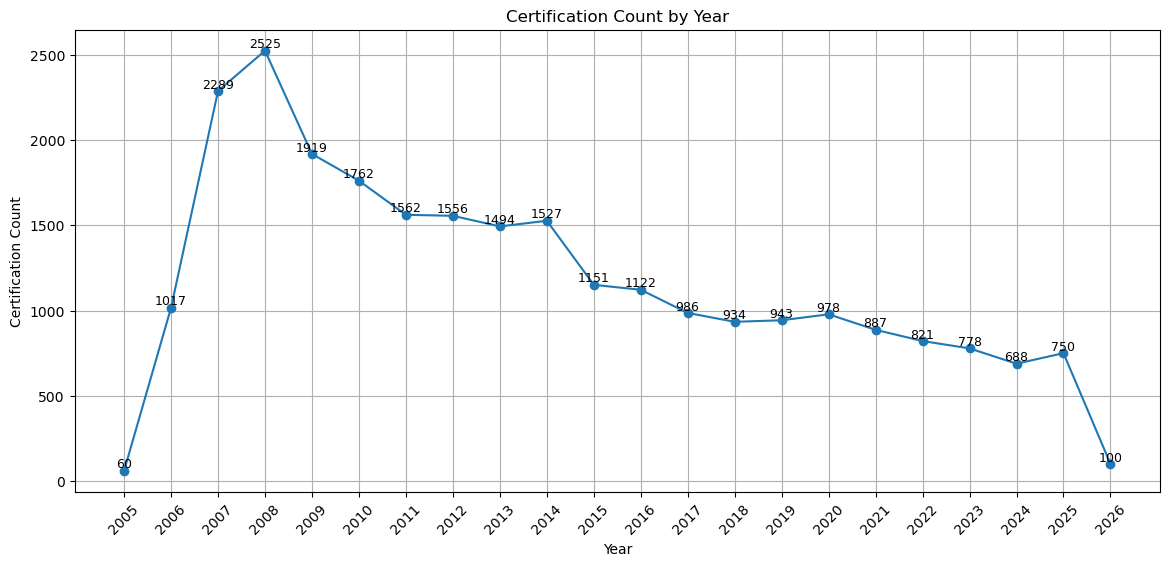

In [59]:
import matplotlib.pyplot as plt

# Annual certification count
yearly_trend = (
    df.groupby(df["certification_date"].dt.year)
    .size()
    .reset_index(name="count")
)

yearly_trend.columns = ["year", "count"]

# Remove missing values
yearly_trend = yearly_trend.dropna()

# Convert year to integer
yearly_trend["year"] = yearly_trend["year"].astype(int)

# Sort by year
yearly_trend = yearly_trend.sort_values("year")

# Create line plot
plt.figure(figsize=(14,6))

plt.plot(
    yearly_trend["year"],
    yearly_trend["count"],
    marker="o"
)

# Add count labels to each point
for i in range(len(yearly_trend)):
    plt.text(
        yearly_trend["year"].iloc[i],
        yearly_trend["count"].iloc[i],
        str(yearly_trend["count"].iloc[i]),
        fontsize=9,
        ha="center",
        va="bottom"
    )

plt.title("Certification Count by Year")
plt.xlabel("Year")
plt.ylabel("Certification Count")

plt.xticks(yearly_trend["year"], rotation=45)

plt.grid(True)

plt.savefig(
    "../outputs/certification_year_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3. Certification Body Analysis

In [61]:
df['certification_body_code'].unique()

array(['AB', 'AI', 'AA', 'AC', 'AK', 'AF', 'AG', 'AD', 'AH', 'AL', 'AM',
       'AO', 'AP', 'AQ'], dtype=object)

In [63]:
df['certification_body_code'].value_counts()

certification_body_code
AG    4329
AA    3944
AK    3582
AF    3412
AD    3391
AB    2673
AI    1388
AC    1357
AL     826
AH     795
AM      89
AO      58
AP       3
AQ       2
Name: count, dtype: int64

In [65]:
body_analysis = (
    df["certification_body_code"]
    .value_counts()
    .reset_index()
)

body_analysis.columns = [
    "certification_body_code",
    "count"
]

body_analysis.style.hide(axis="index")

certification_body_code,count
AG,4329
AA,3944
AK,3582
AF,3412
AD,3391
AB,2673
AI,1388
AC,1357
AL,826
AH,795


In [67]:
import pandas as pd

reference_table = pd.DataFrame({
    "certification_body_code": [
        "AA", "AB", "AC", "AD",
        "AF", "AG", "AH", "AI",
        "AK", "AL", "AM",
        "AO", "AP", "AQ"
    ],
    "certification_body_name": [
        "TÜV SÜD Japan Ltd.",
        "TÜV Rheinland Japan Ltd.",
        "German Quality System Certification Co., Ltd.",
        "BSI Group Japan Co., Ltd.",
        "SGS Japan Co., Ltd.",
        "Cosmos Corporation",
        "Japan Quality Assurance Organization (JQA)",
        "Nanotech Spindler Co., Ltd.",
        "Japan Electrical Safety & Environment Technology Laboratories",
        "Japan Medical Devices Center (a public interest incorporated foundation)",
        "AiCS Inc.",
        "DEKRA Certification Japan Co., Ltd.",
        "Bureau Veritas Japan Co., Ltd.",
        "Intertek Japan Co., Ltd."
    ],
    "certification_body_short_name": [
    "TÜV SÜD",              # TÜV SÜD Japan Ltd.
    "TÜV Rheinland",        # TÜV Rheinland Japan Ltd.
    "GQS Certification",    # German Quality System Certification Co., Ltd.
    "BSI Japan",            # BSI Group Japan Co., Ltd.
    "SGS Japan",            # SGS Japan Co., Ltd.
    "Cosmos",               # Cosmos Corporation
    "JQA",                  # Japan Quality Assurance Organization (JQA)
    "Nanotech Spindler",    # Nanotech Spindler Co., Ltd.
    "JET",                  # Japan Electrical Safety & Environment Technology Laboratories
    "Japan MDC",            # Japan Medical Devices Center (a public interest incorporated foundation)
    "AiCS Inc.",   # AiCS Inc.
    "DEKRA Japan",          # DEKRA Certification Japan Co., Ltd.
    "Bureau Veritas",       # Bureau Veritas Japan Co., Ltd.
    "Intertek Japan"        # Intertek Japan Co., Ltd.
],
    "status": [
        "active", "active", "active", "active",
        "active", "active", "active", "active",
        "active", "active", "abolished",
        "abolished", "abolished", "abolished"
    ],
    "abolished_date": [
        None, None, None, None,
        None, None, None, None,
        None, None, "2023-05-01",
        "2021-03-31", "2018-08-31", "2020-02-29"
    ]
})

reference_table["abolished_date"] = pd.to_datetime(
        reference_table["abolished_date"],
        errors="coerce",
        format="mixed"
)

reference_table.style.hide(axis='index')

certification_body_code,certification_body_name,certification_body_short_name,status,abolished_date
AA,TÜV SÜD Japan Ltd.,TÜV SÜD,active,NaT
AB,TÜV Rheinland Japan Ltd.,TÜV Rheinland,active,NaT
AC,"German Quality System Certification Co., Ltd.",GQS Certification,active,NaT
AD,"BSI Group Japan Co., Ltd.",BSI Japan,active,NaT
AF,"SGS Japan Co., Ltd.",SGS Japan,active,NaT
AG,Cosmos Corporation,Cosmos,active,NaT
AH,Japan Quality Assurance Organization (JQA),JQA,active,NaT
AI,"Nanotech Spindler Co., Ltd.",Nanotech Spindler,active,NaT
AK,Japan Electrical Safety & Environment Technology Laboratories,JET,active,NaT
AL,Japan Medical Devices Center (a public interest incorporated foundation),Japan MDC,active,NaT


In [69]:
reference_table.to_excel(
    "../reference/certification_body_mapping.xlsx",
    index=False
)

print("Saved:")
print("reference/certification_body_mapping.xlsx")

Saved:
reference/certification_body_mapping.xlsx


In [71]:
reference_table.dtypes

certification_body_code                  object
certification_body_name                  object
certification_body_short_name            object
status                                   object
abolished_date                   datetime64[ns]
dtype: object

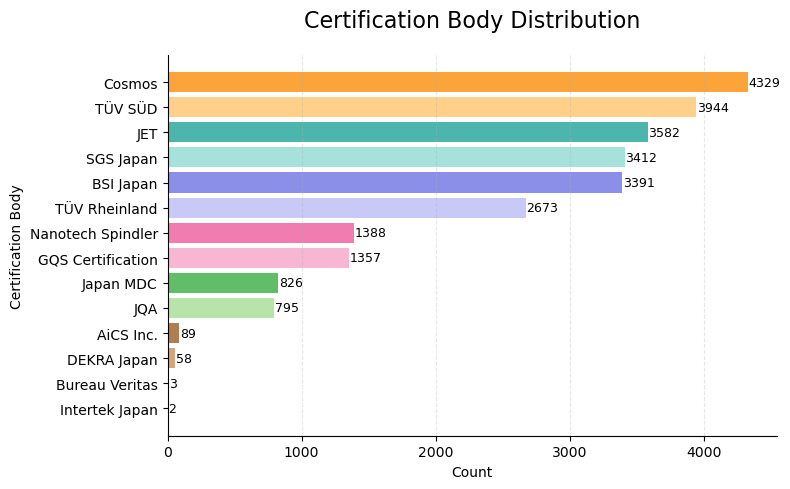

In [75]:
import matplotlib.pyplot as plt

body_analysis_plot = body_analysis.merge(
    reference_table[["certification_body_code", "certification_body_short_name"]],
    on="certification_body_code",
    how="left"
)

body_plot = body_analysis_plot.sort_values(
    by="count",
    ascending=True
)

colors = [
    "#A7D3F2",  "#5DA5DA",
    "#D2A679",  "#B07D52", 
    "#B7E4A8",  "#60BD68",  
    "#F7B6D2",  "#F17CB0",  
    "#C8C9F7",  "#8B8FE8",  
    "#A7E1DB",  "#4DB6AC",  
    "#FFD08A",  "#FAA43A",  
]

plt.figure(figsize=(8, 5))

plt.barh(
    body_plot["certification_body_short_name"],
    body_plot["count"],
    color=colors[:len(body_plot)]
)

for i in range(len(body_plot)):
    plt.text(
        body_plot["count"].iloc[i] + 5,
        i,
        str(body_plot["count"].iloc[i]),
        va="center",
        fontsize=9
    )

plt.title(
    "Certification Body Distribution",
    fontsize=16,
    pad=20
)

plt.xlabel("Count")
plt.ylabel("Certification Body")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(
    axis="x",
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()

plt.savefig(
    "../outputs/certification_body_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 4. Major Vendor Analysis

In [77]:
vendor_top10 = (
    df['vendor_name_certified_person']
    .value_counts()
    .head(10)
)

print(vendor_top10)

vendor_name_certified_person
富士フイルム株式会社             723
オリンパスメディカルシステムズ株式会社    676
大東電機工業株式会社             391
リオン株式会社                328
ＧＥヘルスケア・ジャパン株式会社       324
キヤノンメディカルシステムズ株式会社     293
オムロンヘルスケア株式会社          282
株式会社松風                 247
株式会社ジーシー               234
株式会社フジ医療器              231
Name: count, dtype: int64


In [79]:
vendor_top10 = (
    df["vendor_name_certified_person"]
    .value_counts()
    .head(10)
    .reset_index()
)

vendor_top10.columns = [
    "vendor_name",
    "count"
]

vendor_top10.style.hide(axis="index")

vendor_name,count
富士フイルム株式会社,723
オリンパスメディカルシステムズ株式会社,676
大東電機工業株式会社,391
リオン株式会社,328
ＧＥヘルスケア・ジャパン株式会社,324
キヤノンメディカルシステムズ株式会社,293
オムロンヘルスケア株式会社,282
株式会社松風,247
株式会社ジーシー,234
株式会社フジ医療器,231


In [81]:
vendor_translation = {
    "富士フイルム株式会社": "FUJIFILM Corporation",
    "オリンパスメディカルシステムズ株式会社": "Olympus Medical Systems Corporation",
    "大東電機工業株式会社": "Daito Electric Machine Industry Co., Ltd.",
    "リオン株式会社": "RION Co., Ltd.",
    "ＧＥヘルスケア・ジャパン株式会社": "GE Healthcare Japan Corporation",
    "キヤノンメディカルシステムズ株式会社": "Canon Medical Systems Corporation",
    "オムロンヘルスケア株式会社": "OMRON Healthcare Co., Ltd.",
    "株式会社松風": "SHOFU Inc.",
    "株式会社ジーシー": "GC Corporation",
    "株式会社フジ医療器": "Fujiiryoki Co., Ltd."
}

vendor_top10["vendor_name_english"] = (
    vendor_top10["vendor_name"]
    .map(vendor_translation)
)

vendor_top10 = vendor_top10[[
    "vendor_name",
    "vendor_name_english",
    "count"
]]

vendor_top10.style.hide(axis="index")

vendor_name,vendor_name_english,count
富士フイルム株式会社,FUJIFILM Corporation,723
オリンパスメディカルシステムズ株式会社,Olympus Medical Systems Corporation,676
大東電機工業株式会社,"Daito Electric Machine Industry Co., Ltd.",391
リオン株式会社,"RION Co., Ltd.",328
ＧＥヘルスケア・ジャパン株式会社,GE Healthcare Japan Corporation,324
キヤノンメディカルシステムズ株式会社,Canon Medical Systems Corporation,293
オムロンヘルスケア株式会社,"OMRON Healthcare Co., Ltd.",282
株式会社松風,SHOFU Inc.,247
株式会社ジーシー,GC Corporation,234
株式会社フジ医療器,"Fujiiryoki Co., Ltd.",231


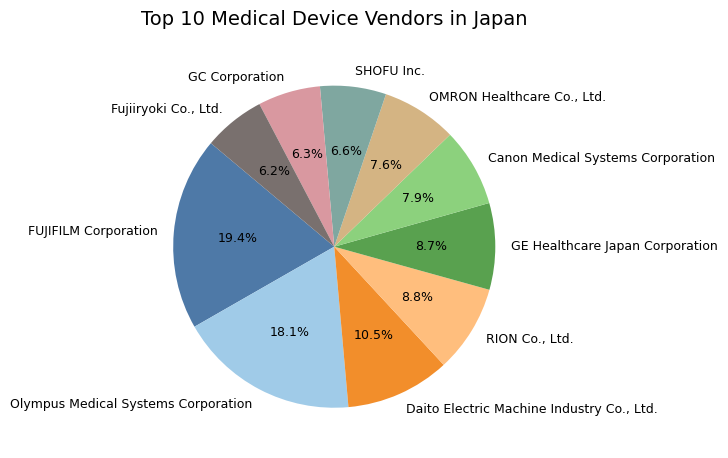

In [87]:
import matplotlib.pyplot as plt

# Corporate Style Palette
colors = [
    "#4E79A7",  "#A0CBE8",  
    "#F28E2B",  "#FFBE7D",  
    "#59A14F", "#8CD17D",  
    "#D4B483",  "#7FA7A0",  
    "#D998A0",  "#79706E"   
]

plt.figure(figsize=(7,7))

# Pie chart
plt.pie(
    vendor_top10["count"],
    labels=vendor_top10["vendor_name_english"],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize':9}
)

plt.title(
    "Top 10 Medical Device Vendors in Japan",
    fontsize=14,
    pad=15
)

plt.tight_layout()

plt.savefig(
    "../outputs/vendor_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()